# EEC Comparison Plots

This notebook reads the saved percentile-summary `pkl` files from two cards and produces the four comparison figures:

- SIDIS `A_{UT,EEC}^{\sin(\phi+\phi_S)}`
- `e^+e^-` `A_{UT,EEC}^{\cos(\phi+ar{\phi})}`
- unpolarized `EEC^{e^+e^-}`
- SIDIS unpolarized `EEC`

The plotting style is adapted from the last plot in `ref.ipynb`, but without the ratio panels.


In [1]:
from pathlib import Path
import pickle

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


## Settings


In [2]:
card_name_w = "Default"
card_name_wo = "Default_noLQCD"

label_w = "wLQCD"
label_wo = "woLQCD"

plot_data_dir = Path("Plot_Data")
figure_dir = plot_data_dir / "Figures"
figure_dir.mkdir(parents=True, exist_ok=True)

sidis_plot_filename = "sidis_aut.pkl"
sidis_eec_plot_filename = "sidis_eec.pkl"
sidis_eec_card_name = "Default"
ee_aut_plot_filename = "ee_aut.pkl"
ee_eec_plot_filename = "ee_eec.pkl"

save_png = False
save_pdf = True

# Tune these first to match the paper text size after figure scaling.
shared_size = 25
axis_label_fontsize = shared_size + 2
chi_xlabel_fontsize = axis_label_fontsize + 2
chi_xlabel = r"$\chi$ (deg)"
ylabel_pad = 20
tick_label_fontsize = shared_size
panel_label_fontsize = shared_size
scale_note_fontsize = shared_size
legend_fontsize = shared_size - 1
text_fontweight = 550

major_tick_length = 12
minor_tick_length = 8
major_tick_width = 1.6
minor_tick_width = 1.2
axis_spine_width = 1.2
panel_title_pad = 10
branch_legend_label_w = "JAMDiFF w/LQCD"
branch_legend_label_wo = "JAMDiFF no LQCD"
branch_legend_loc = "upper left"
branch_legend_anchor = (0.02, 0.78)
aut_layout_top = 0.90
ee_eec_layout_top = 0.98

wLQCD_band_alpha = 1.0
woLQCD_band_alpha = 0.45
hatch_linewidth = 2.5
hatched_band_boundary_linewidth = hatch_linewidth

sidis_figsize = (24, 8)
ee_aut_figsize = (24, 8)
ee_eec_figsize = (12, 7.5)
subplot_w_pad = 3

chi_deg_range = (0.1, 45.0)
aut_xlim = chi_deg_range
ee_eec_xlim = chi_deg_range
sidis_eec_xlim = chi_deg_range
shared_chi_xticks = [10, 20, 30, 40]
sidis_eec_xticks = shared_chi_xticks
sidis_eec_q_compare_x = 0.30
sidis_eec_q_compare_q_values = [2.0, 10.0]

sidis_eec_q2_plot_factor = 1.0
sidis_eec_high_q_plot_factor = 50.0

ee_eec_y_scale = 1.0
sidis_aut_ylabel = r"$A_{UT,\mathrm{EEC}\,\mathrm{SIDIS}}^{\sin(\phi+\phi_S)}$"
ee_aut_ylabel = r"$A_{\mathrm{EEC}\,e^+e^-}^{\cos(\phi+\bar{\phi})}$"
ee_eec_ylabel = r"$\mathrm{EEC}^{\pi}_{e^+e^-}$"
sidis_eec_ylabel = r"$\mathrm{EEC}_{\mathrm{SIDIS}}\;(\mathrm{GeV}^{-2})$"

sidis_panel_ylims = {
    0.01: (0.0, 0.008),
    0.10: (0.0, 0.08),
    0.30: (0.0, 0.23),
}
sidis_panel_yticks = {
    0.01: [0.001, 0.003, 0.005, 0.007],
    0.10: [0.01, 0.03, 0.05, 0.07],
    0.30: [0.05, 0.1, 0.15, 0.2],
}

ee_aut_panel_ylims = {
    1.00: (0.0, 0.0225),
    15.0: (0.0, 0.027),
    30.0: (0.0, 0.09),
}
ee_aut_panel_yticks = {
    1.00: [0.005, 0.01, 0.015, 0.02],
    15.0: [0.006, 0.012, 0.018, 0.024],
    30.0: [0.02, 0.04, 0.06, 0.08],
}

ee_eec_ylim = (0.0, 0.02)
ee_eec_yticks = [0.004, 0.008, 0.012, 0.016]
   

sidis_eec_panel_ylims = {
    0.01: (0.0, 0.03),
    0.10: (0.0, 0.015),
    0.30: (0.0, 0.01),
}

sidis_eec_panel_yticks = {
    0.01: [0.006, 0.012, 0.018, 0.024],
    0.10: [0.003, 0.006, 0.009, 0.012],
    0.30: [0.002, 0.004, 0.006, 0.008],
}

sidis_eec_q_compare_ylim = (0.0, 0.6)
sidis_eec_q_compare_yticks = [0.12, 0.24, 0.36, 0.48]

## Load Plot Data


In [3]:
def _load_plot_payload(card_name, filename):
    path = plot_data_dir / card_name / filename
    if not path.exists():
        raise FileNotFoundError(f"Missing plot data file: {path}")
    with path.open("rb") as f:
        payload = pickle.load(f)
    return payload, path


def _describe_payload(name, payload, path):
    print(f"{name}: {path}")
    print(f"  process={payload['process']}, scan={payload['scan_label']}, replicas={len(payload['replica_ids'])}, coeffs={len(payload['coeff_grid'])}")


sidis_w, sidis_w_path = _load_plot_payload(card_name_w, sidis_plot_filename)
sidis_wo, sidis_wo_path = _load_plot_payload(card_name_wo, sidis_plot_filename)

ee_aut_wo, ee_aut_wo_path = _load_plot_payload(card_name_wo, ee_aut_plot_filename)

ee_eec_wo, ee_eec_wo_path = _load_plot_payload(card_name_wo, ee_eec_plot_filename)

_describe_payload("SIDIS", sidis_w, sidis_w_path)
_describe_payload("SIDIS", sidis_wo, sidis_wo_path)
_describe_payload("EE AUT", ee_aut_wo, ee_aut_wo_path)
_describe_payload("EE EEC", ee_eec_wo, ee_eec_wo_path)


SIDIS: Plot_Data/Default/sidis_aut.pkl
  process=SIDIS_AUT, scan=a_b_corrected_area_uniform_200, replicas=969, coeffs=200
SIDIS: Plot_Data/Default_noLQCD/sidis_aut.pkl
  process=SIDIS_AUT, scan=a_b_corrected_area_uniform_200, replicas=975, coeffs=200
EE AUT: Plot_Data/Default_noLQCD/ee_aut.pkl
  process=EE_AUT, scan=a_b_corrected_area_uniform_200, replicas=975, coeffs=200
EE EEC: Plot_Data/Default_noLQCD/ee_eec.pkl
  process=EE_EEC, scan=a_b_corrected_area_uniform_200, replicas=975, coeffs=200


## Plotting Helpers


In [4]:
props = dict(boxstyle="round", facecolor="white", alpha=0)

blue = (87 / 255, 144 / 255, 252 / 255)
orange = (248 / 255, 156 / 255, 32 / 255)
red = (228 / 255, 37 / 255, 54 / 255)
purple1 = (150 / 255, 74 / 255, 139 / 255)
gray = (156 / 255, 156 / 255, 156 / 255)
purple2 = (122 / 255, 33 / 255, 221 / 255)

color_cycle = [blue, red, orange, purple1, gray, purple2, "black"]
branch_alpha = {label_w: wLQCD_band_alpha, label_wo: woLQCD_band_alpha}
branch_hatch = {label_w: "\\", label_wo: None}

mpl.rcParams["hatch.linewidth"] = hatch_linewidth
mpl.rcParams["font.weight"] = text_fontweight
mpl.rcParams["axes.labelweight"] = text_fontweight
mpl.rcParams["axes.titleweight"] = text_fontweight
mpl.rcParams["mathtext.default"] = "it"


def _bold_axis_text(ax):
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight(text_fontweight)
    ax.xaxis.label.set_fontweight(text_fontweight)
    ax.yaxis.label.set_fontweight(text_fontweight)
    ax.title.set_fontweight(text_fontweight)


def _style_axis(ax):
    ax.minorticks_on()
    ax.tick_params(axis="both", direction="in", length=major_tick_length, width=major_tick_width, labelsize=tick_label_fontsize, top=True, right=True)
    ax.tick_params(axis="both", which="minor", direction="in", length=minor_tick_length, width=minor_tick_width, labelsize=tick_label_fontsize, top=True, right=True)
    _bold_axis_text(ax)
    for spine in ax.spines.values():
        spine.set_linewidth(axis_spine_width)
    ax.grid(False)


def _bold_legend(legend):
    if legend is not None:
        for text in legend.get_texts():
            text.set_fontweight(text_fontweight)
    return legend


def _branch_handles():
    return [
        Patch(facecolor="white", edgecolor="black", hatch=branch_hatch[label_w], linewidth=hatched_band_boundary_linewidth, label=branch_legend_label_w),
        Patch(facecolor="0.55", edgecolor="none", alpha=0.30, label=branch_legend_label_wo),
    ]


def _add_branch_legend(ax):
    existing_legend = ax.get_legend()
    if existing_legend is not None:
        ax.add_artist(existing_legend)
    _bold_legend(ax.legend(
        handles=_branch_handles(),
        frameon=False,
        prop={"weight": text_fontweight, "size": legend_fontsize},
        loc=branch_legend_loc,
        bbox_to_anchor=branch_legend_anchor,
        ncol=1,
        handlelength=2.0,
        handletextpad=0.5,
    ))


def _q_handles(q_values, colors):
    return [
        Patch(facecolor=color, edgecolor=color, alpha=0.25, label=rf"$Q={float(Q):g}\,\mathrm{{GeV}}$")
        for Q, color in zip(q_values, colors)
    ]


def _save_figure(fig, stem):
    saved = []
    if save_png:
        png_path = figure_dir / f"{stem}.png"
        fig.savefig(png_path, dpi=300, bbox_inches="tight")
        saved.append(png_path)
    if save_pdf:
        pdf_path = figure_dir / f"{stem}.pdf"
        fig.savefig(pdf_path, bbox_inches="tight")
        saved.append(pdf_path)
    for path in saved:
        print(f"saved: {path}")


def _assert_same_scan(payload_a, payload_b, *, label):
    if payload_a["scan_label"] != payload_b["scan_label"]:
        raise ValueError(f"{label}: scan label mismatch: {payload_a['scan_label']} vs {payload_b['scan_label']}")
    if np.asarray(payload_a["coeff_grid"]).shape != np.asarray(payload_b["coeff_grid"]).shape:
        raise ValueError(f"{label}: coefficient-grid shape mismatch")


def _assert_same_chi(entry_a, entry_b, *, label):
    chi_a = np.asarray(entry_a["chi_deg"], dtype=float)
    chi_b = np.asarray(entry_b["chi_deg"], dtype=float)
    if chi_a.shape != chi_b.shape or not np.allclose(chi_a, chi_b):
        raise ValueError(f"{label}: chi grid mismatch")
    return chi_a


def _w_hatch_for_q(q, q_values):
    if q_values is None:
        return branch_hatch[label_w]
    q_min = min(float(value) for value in q_values)
    return "/" if np.isclose(float(q), q_min) else branch_hatch[label_w]


def _fill_band(ax, chi_deg, lower, upper, color, *, branch_label, zorder=1, hatch_override=None):
    hatch = hatch_override if hatch_override is not None else branch_hatch[branch_label]
    if hatch:
        kwargs = dict(facecolor="none", edgecolor=color, hatch=hatch, linewidth=hatched_band_boundary_linewidth, alpha=0.72, zorder=zorder)
    else:
        kwargs = dict(facecolor=color, edgecolor="none", linewidth=0.0, alpha=branch_alpha[branch_label], zorder=zorder)
    ax.fill_between(chi_deg, lower, upper, **kwargs)


def _add_pair(ax, chi_deg, entry_w, entry_wo, color, *, q=None, q_values=None):
    lower_w = np.asarray(entry_w["lower_68"], dtype=float)
    upper_w = np.asarray(entry_w["upper_68"], dtype=float)
    lower_wo = np.asarray(entry_wo["lower_68"], dtype=float)
    upper_wo = np.asarray(entry_wo["upper_68"], dtype=float)

    _fill_band(ax, chi_deg, lower_wo, upper_wo, color, branch_label=label_wo, zorder=1)
    _fill_band(ax, chi_deg, lower_w, upper_w, color, branch_label=label_w, zorder=2, hatch_override=_w_hatch_for_q(q, q_values))

    return [lower_w, upper_w, lower_wo, upper_wo]


def _nice_zero_based_ticks(ymax, max_ticks=4):
    if np.isclose(ymax, 0.0):
        return np.array([0.0, 0.05])

    raw_step = ymax / max(max_ticks - 1, 1)
    exponent = np.floor(np.log10(raw_step))
    scale = 10 ** exponent

    for mult in (1.0, 1.5, 2.0, 2.5, 5.0, 10.0):
        step = mult * scale
        tick_count = int(np.ceil(ymax / step)) + 1
        if tick_count <= max_ticks:
            top = step * (tick_count - 1)
            return np.linspace(0.0, top, tick_count)

    step = 10.0 * scale
    tick_count = int(np.ceil(ymax / step)) + 1
    top = step * (tick_count - 1)
    return np.linspace(0.0, top, tick_count)


def _set_panel_ylim(ax, arrays, manual_ylim=None, manual_yticks=None):
    if manual_ylim is not None:
        ax.set_ylim(*manual_ylim)
        if manual_yticks is not None:
            ax.set_yticks(manual_yticks)
        _bold_axis_text(ax)
        return

    if manual_yticks is not None:
        ax.set_ylim(float(manual_yticks[0]), float(manual_yticks[-1]))
        ax.set_yticks(manual_yticks)
        _bold_axis_text(ax)
        return

    ymax = float(np.nanmax([np.nanmax(np.asarray(arr, dtype=float)) for arr in arrays]))
    ticks = _nice_zero_based_ticks(ymax, max_ticks=4)
    ax.set_ylim(0.0, float(ticks[-1]))
    ax.set_yticks(ticks)
    _bold_axis_text(ax)


## SIDIS Comparison


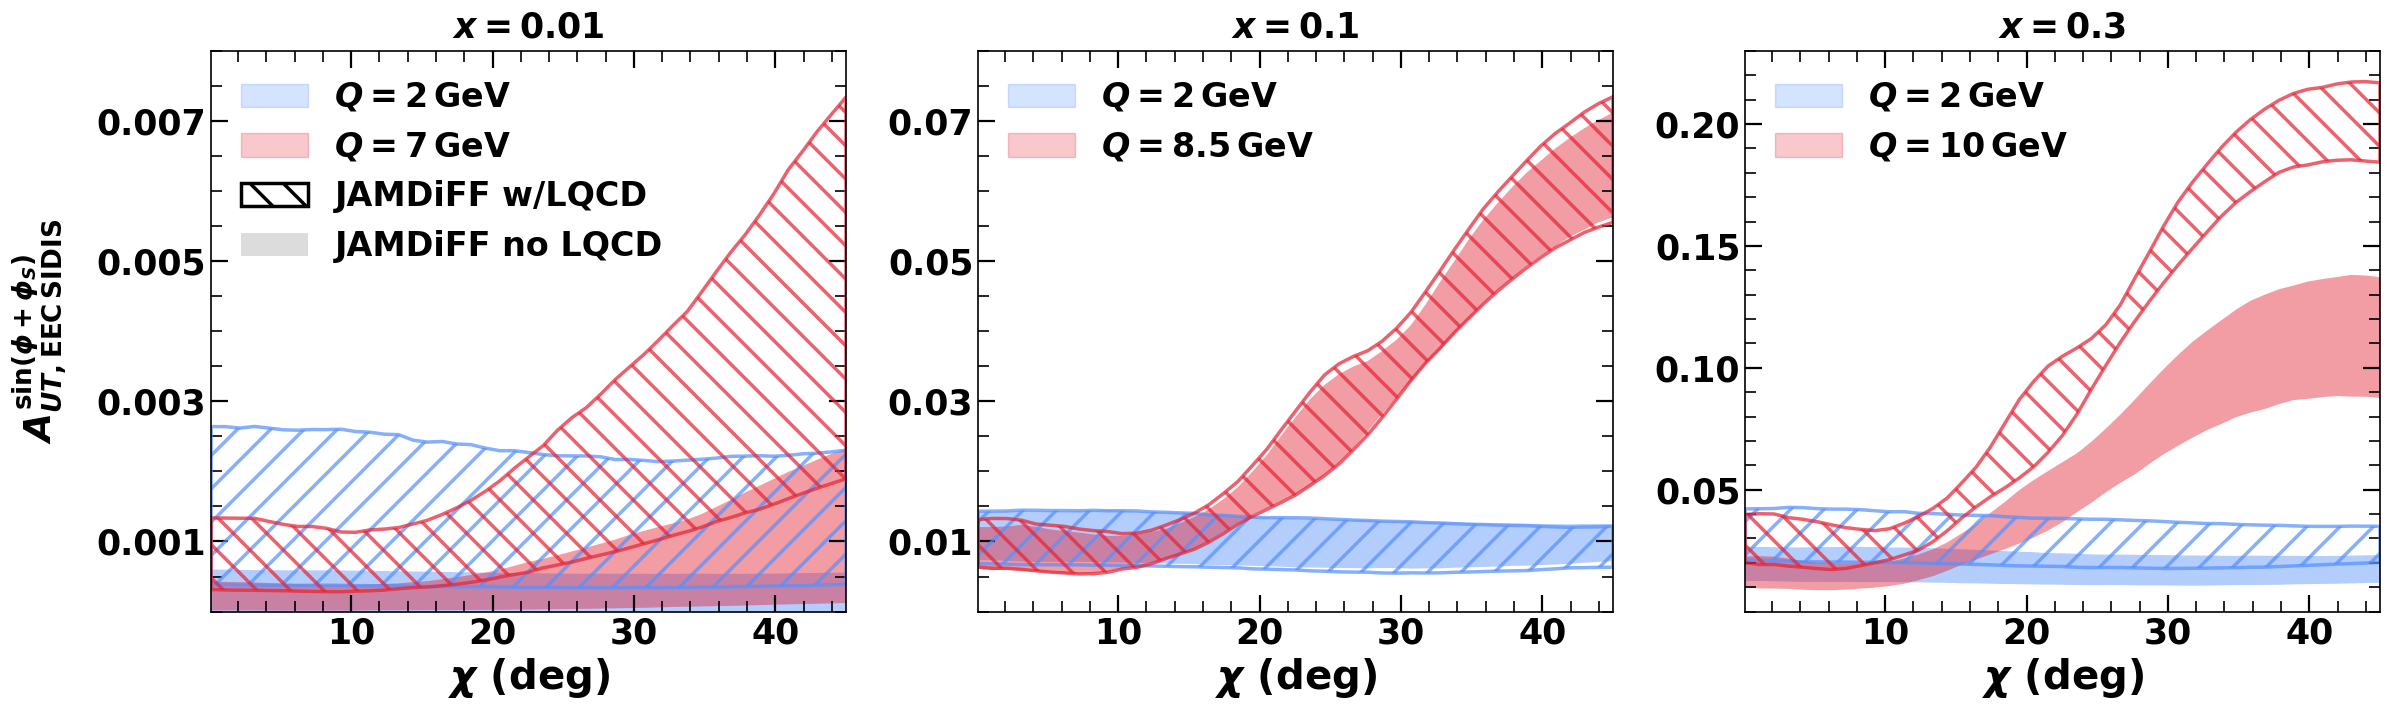

saved: Plot_Data/Figures/sidis_aut_compare.pdf


In [5]:
_assert_same_scan(sidis_w, sidis_wo, label="SIDIS")

x_values = [float(x) for x in sidis_w["x_values"]]
fig, axes = plt.subplots(1, len(x_values), figsize=sidis_figsize, sharex=True, sharey=False)
axes = np.atleast_1d(axes)

for ifig, (ax, x) in enumerate(zip(axes, x_values)):
    q_values = [float(Q) for Q in sidis_w["x_to_q"][x]]
    colors = color_cycle[:len(q_values)]
    panel_bounds = []

    for color, Q in zip(colors, q_values):
        key = (float(x), float(Q))
        entry_w = sidis_w["by_kinematics"][key]
        entry_wo = sidis_wo["by_kinematics"][key]
        chi_deg = _assert_same_chi(entry_w, entry_wo, label=f"SIDIS x={x:g}, Q={Q:g}")
        panel_bounds.extend(_add_pair(ax, chi_deg, entry_w, entry_wo, color, q=Q, q_values=q_values))

    panel_key = round(float(x), 2)
    _style_axis(ax)
    ax.set_xlim(*aut_xlim)
    ax.set_xticks(shared_chi_xticks)
    ax.set_xlabel(chi_xlabel, fontsize=chi_xlabel_fontsize, fontweight=text_fontweight)
    ax.set_title(rf"$x = {x:g}$", fontsize=panel_label_fontsize, fontweight=text_fontweight, pad=panel_title_pad)
    _set_panel_ylim(ax, panel_bounds, manual_ylim=sidis_panel_ylims.get(panel_key), manual_yticks=sidis_panel_yticks.get(panel_key))

    legend_handles = _q_handles(q_values, colors)
    if ifig == 0:
        legend_handles = legend_handles + _branch_handles()
    _bold_legend(ax.legend(handles=legend_handles, frameon=False, prop={"weight": text_fontweight, "size": legend_fontsize}, loc="upper left"))

axes[0].set_ylabel(sidis_aut_ylabel, fontsize=axis_label_fontsize, fontweight=text_fontweight, labelpad=ylabel_pad)
fig.tight_layout(w_pad=subplot_w_pad, rect=(0.0, 0.0, 1.0, aut_layout_top))
plt.show()
_save_figure(fig, "sidis_aut_compare")


## `e^+e^-` AUT no LQCD


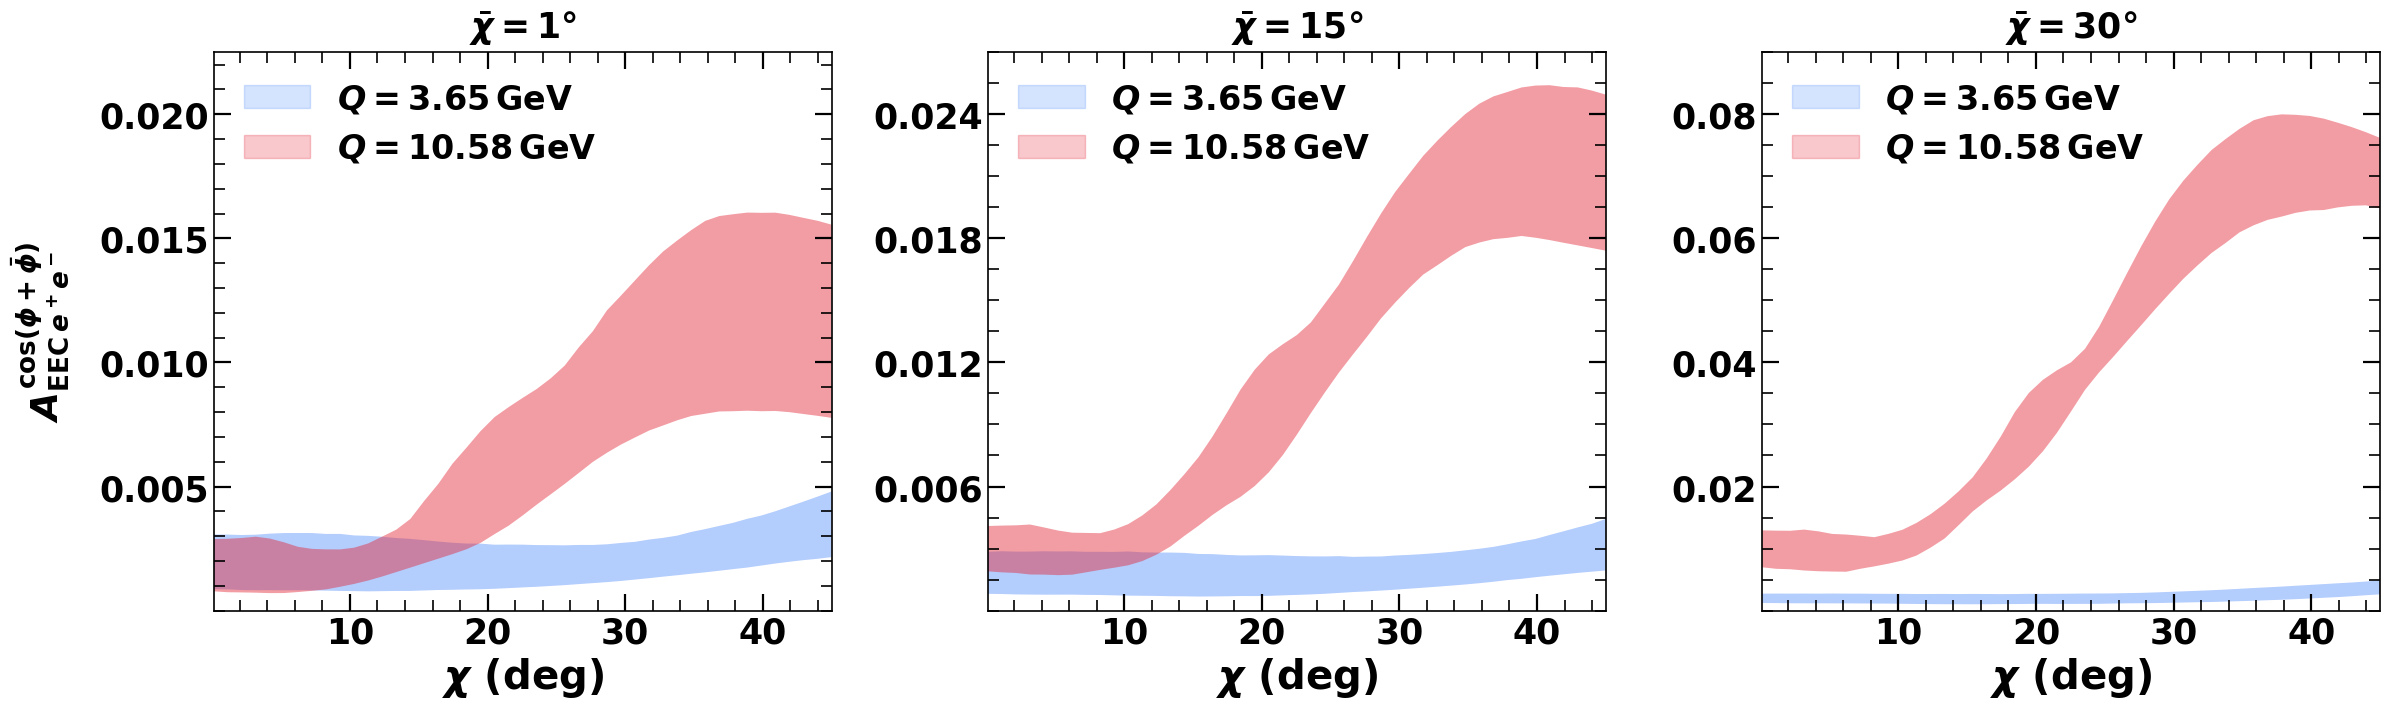

saved: Plot_Data/Figures/ee_aut_compare.pdf


In [6]:
chibar_values = [float(value) for value in ee_aut_wo["chibar_deg_list"]]
q_values = [float(value) for value in ee_aut_wo["Q_list"]]
colors = color_cycle[:len(q_values)]

fig, axes = plt.subplots(1, len(chibar_values), figsize=ee_aut_figsize, sharex=True, sharey=False)
axes = np.atleast_1d(axes)

for ax, chibar_deg in zip(axes, chibar_values):
    panel_bounds = []

    for color, Q in zip(colors, q_values):
        key = (float(chibar_deg), float(Q))
        entry = ee_aut_wo["by_kinematics"][key]
        chi_deg = np.asarray(entry["chi_deg"], dtype=float)
        lower = np.asarray(entry["lower_68"], dtype=float)
        upper = np.asarray(entry["upper_68"], dtype=float)
        _fill_band(ax, chi_deg, lower, upper, color, branch_label=label_wo, zorder=1)
        panel_bounds.extend([lower, upper])

    panel_key = round(float(chibar_deg), 2)
    _style_axis(ax)
    ax.set_xlim(*aut_xlim)
    ax.set_xticks(shared_chi_xticks)
    ax.set_xlabel(chi_xlabel, fontsize=chi_xlabel_fontsize, fontweight=text_fontweight)
    ax.set_title(rf"$\bar{{\chi}} = {chibar_deg:g}$°", fontsize=panel_label_fontsize, fontweight=text_fontweight, pad=panel_title_pad)
    _set_panel_ylim(ax, panel_bounds, manual_ylim=ee_aut_panel_ylims.get(panel_key), manual_yticks=ee_aut_panel_yticks.get(panel_key))

    _bold_legend(ax.legend(handles=_q_handles(q_values, colors), frameon=False, prop={"weight": text_fontweight, "size": legend_fontsize}, loc="upper left"))

axes[0].set_ylabel(ee_aut_ylabel, fontsize=axis_label_fontsize, fontweight=text_fontweight, labelpad=ylabel_pad)
fig.tight_layout(w_pad=subplot_w_pad, rect=(0.0, 0.0, 1.0, aut_layout_top))
plt.show()
_save_figure(fig, "ee_aut_compare")


## Unpolarized `e^+e^-` EEC no LQCD


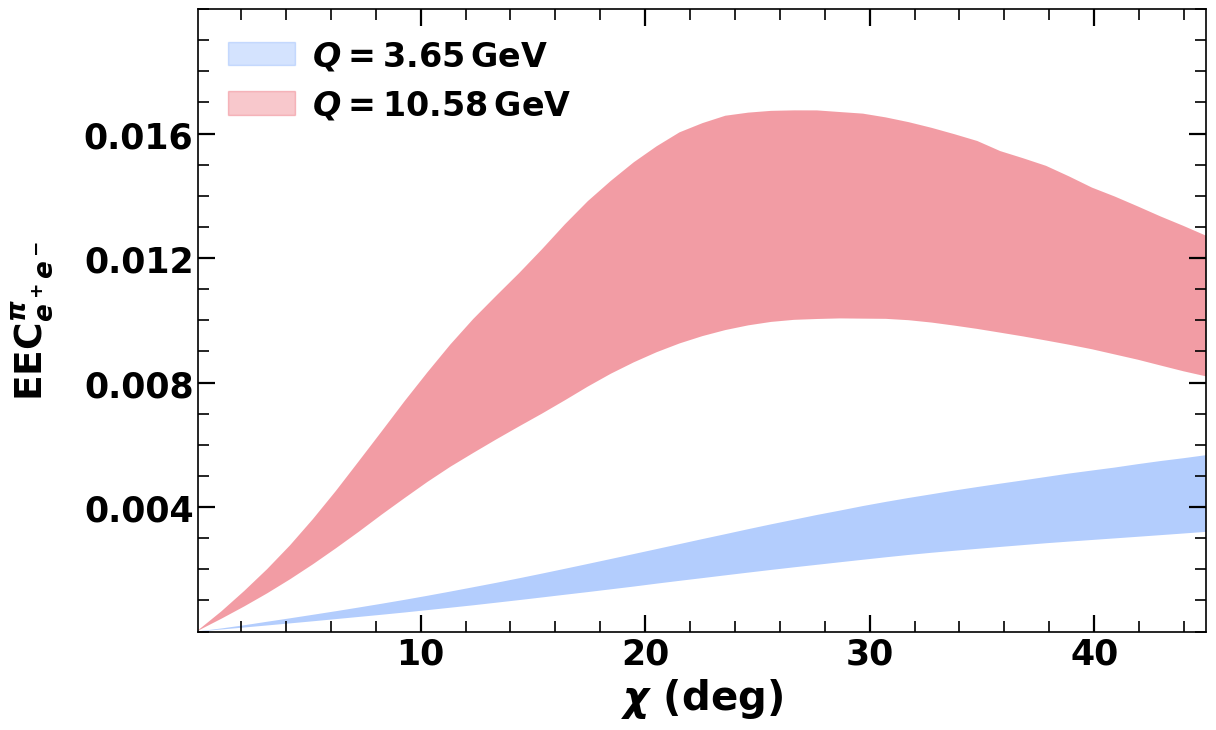

saved: Plot_Data/Figures/ee_eec_compare.pdf


In [7]:
q_values = [float(value) for value in ee_eec_wo["Q_list"]]
colors = color_cycle[:len(q_values)]

fig, ax = plt.subplots(1, 1, figsize=ee_eec_figsize)
panel_bounds = []

for color, Q in zip(colors, q_values):
    entry = ee_eec_wo["by_kinematics"][float(Q)]
    chi_deg = np.asarray(entry["chi_deg"], dtype=float)

    lower = ee_eec_y_scale * np.asarray(entry["lower_68"], dtype=float)
    upper = ee_eec_y_scale * np.asarray(entry["upper_68"], dtype=float)

    _fill_band(ax, chi_deg, lower, upper, color, branch_label=label_wo, zorder=1)

    panel_bounds.extend([lower, upper])

_style_axis(ax)
ax.set_xlim(*ee_eec_xlim)
ax.set_xticks(shared_chi_xticks)
_set_panel_ylim(ax, panel_bounds, manual_ylim=ee_eec_ylim, manual_yticks=ee_eec_yticks)
ax.set_xlabel(chi_xlabel, fontsize=chi_xlabel_fontsize, fontweight=text_fontweight)
ax.set_ylabel(ee_eec_ylabel, fontsize=axis_label_fontsize, fontweight=text_fontweight, labelpad=ylabel_pad)
_bold_legend(ax.legend(
    handles=_q_handles(q_values, colors),
    frameon=False,
    prop={"weight": text_fontweight, "size": legend_fontsize},
    loc="upper left",
    handlelength=2.0,
    handletextpad=0.5,
))
fig.subplots_adjust(left=0.14, right=0.98, bottom=0.15, top=ee_eec_layout_top)
plt.show()
_save_figure(fig, "ee_eec_compare")


## SIDIS EEC


SIDIS EEC: Plot_Data/Default/sidis_eec.pkl


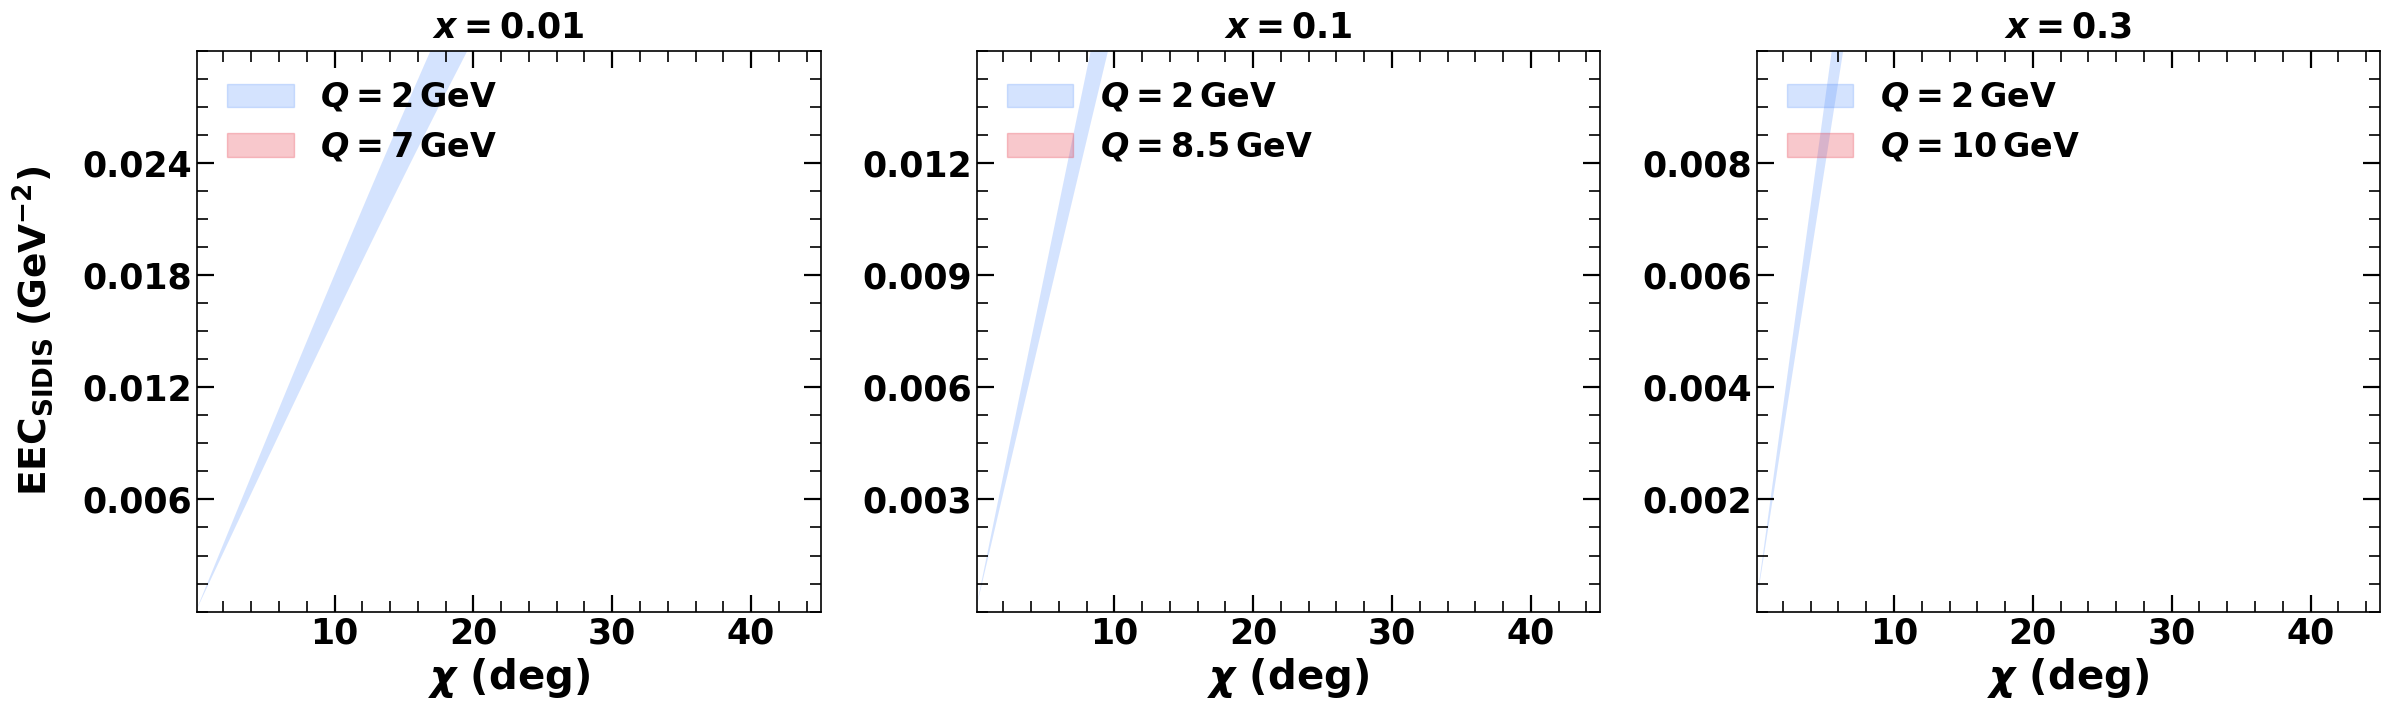

saved: Plot_Data/Figures/sidis_eec_compare.pdf


In [8]:
sidis_eec_data, sidis_eec_path = _load_plot_payload(sidis_eec_card_name, sidis_eec_plot_filename)

print(f"SIDIS EEC: {sidis_eec_path}")

x_values = [float(x) for x in sidis_eec_data["x_values"]]

fig, axes = plt.subplots(1, len(x_values), figsize=sidis_figsize, sharex=True, sharey=False)
axes = np.atleast_1d(axes)

for ax, x in zip(axes, x_values):
    q_values = [float(Q) for Q in sidis_eec_data["x_to_q"][x]]
    colors = color_cycle[:len(q_values)]
    panel_bounds = []

    for color, Q in zip(colors, q_values):
        key = (float(x), float(Q))
        entry = sidis_eec_data["by_kinematics"][key]
        plot_factor = sidis_eec_q2_plot_factor if np.isclose(float(Q), 2.0) else sidis_eec_high_q_plot_factor
        chi_deg = np.asarray(entry["chi_deg"], dtype=float)
        lower = plot_factor * np.asarray(entry["lower_68"], dtype=float)
        upper = plot_factor * np.asarray(entry["upper_68"], dtype=float)
        ax.fill_between(chi_deg, lower, upper, facecolor=color, edgecolor="none", linewidth=0.0, alpha=0.25, zorder=1)
        panel_bounds.extend([lower, upper])
        if not np.isclose(float(Q), 2.0) and not np.isclose(plot_factor, 1.0):
            label_idx = int(0.82 * (len(chi_deg) - 1))
            label_y = upper[label_idx]
            ax.annotate(rf"$\times {plot_factor:g}$", xy=(chi_deg[label_idx], label_y), xytext=(0, 8), textcoords="offset points", color=color, fontsize=legend_fontsize, fontweight=text_fontweight, ha="center", va="bottom", zorder=4)

    _style_axis(ax)
    ax.set_xlim(*sidis_eec_xlim)
    ax.set_xticks(sidis_eec_xticks)
    ax.set_xlabel(chi_xlabel, fontsize=chi_xlabel_fontsize, fontweight=text_fontweight)
    ax.set_title(rf"$x = {x:g}$", fontsize=panel_label_fontsize, fontweight=text_fontweight, pad=panel_title_pad)
    panel_key = round(float(x), 2)
    _set_panel_ylim(ax, panel_bounds, manual_ylim=sidis_eec_panel_ylims.get(panel_key), manual_yticks=sidis_eec_panel_yticks.get(panel_key))

    legend_handles = _q_handles(q_values, colors)
    _bold_legend(ax.legend(handles=legend_handles, frameon=False, prop={"weight": text_fontweight, "size": legend_fontsize}, loc="upper left"))

axes[0].set_ylabel(sidis_eec_ylabel, fontsize=axis_label_fontsize, fontweight=text_fontweight, labelpad=ylabel_pad)
fig.tight_layout(w_pad=subplot_w_pad, rect=(0.0, 0.0, 1.0, aut_layout_top))
plt.show()
_save_figure(fig, "sidis_eec_compare")


## SIDIS EEC Q Comparison


SIDIS EEC: Plot_Data/Default/sidis_eec.pkl


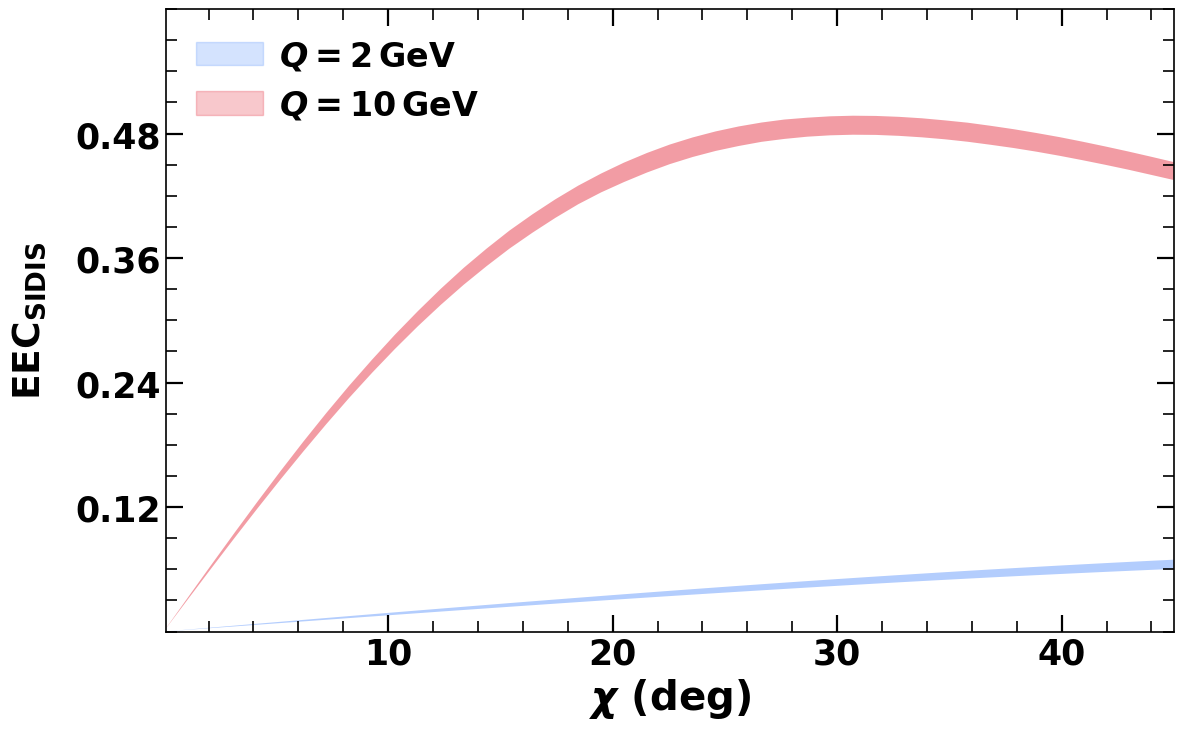

saved: Plot_Data/Figures/sidis_eec_q_compare.pdf


In [9]:
sidis_eec_data, sidis_eec_path = _load_plot_payload(sidis_eec_card_name, sidis_eec_plot_filename)

print(f"SIDIS EEC: {sidis_eec_path}")

x = float(sidis_eec_q_compare_x)
q_values = [float(Q) for Q in sidis_eec_q_compare_q_values]
colors = color_cycle[:len(q_values)]

fig, ax = plt.subplots(1, 1, figsize=ee_eec_figsize)
panel_bounds = []

for color, Q in zip(colors, q_values):
    key = (x, float(Q))
    if key not in sidis_eec_data["by_kinematics"]:
        raise KeyError(f"SIDIS EEC payload does not contain x={x:g}, Q={Q:g}")
    entry = sidis_eec_data["by_kinematics"][key]
    chi_deg = np.asarray(entry["chi_deg"], dtype=float)

    lower = np.asarray(entry["lower_68"], dtype=float)
    upper = np.asarray(entry["upper_68"], dtype=float)

    _fill_band(ax, chi_deg, lower, upper, color, branch_label=label_wo, zorder=1)

    panel_bounds.extend([lower, upper])

_style_axis(ax)
ax.set_xlim(*sidis_eec_xlim)
ax.set_xticks(sidis_eec_xticks)
_set_panel_ylim(ax, panel_bounds, manual_ylim=sidis_eec_q_compare_ylim, manual_yticks=sidis_eec_q_compare_yticks)
ax.set_xlabel(chi_xlabel, fontsize=chi_xlabel_fontsize, fontweight=text_fontweight)
ax.set_ylabel(r"$\mathrm{EEC}_{\mathrm{SIDIS}}$", fontsize=axis_label_fontsize, fontweight=text_fontweight, labelpad=ylabel_pad)
_bold_legend(ax.legend(
    handles=_q_handles(q_values, colors),
    frameon=False,
    prop={"weight": text_fontweight, "size": legend_fontsize},
    loc="upper left",
    handlelength=2.0,
    handletextpad=0.5,
))
fig.subplots_adjust(left=0.14, right=0.98, bottom=0.15, top=ee_eec_layout_top)
plt.show()
_save_figure(fig, "sidis_eec_q_compare")
